- # Installation

In [1]:
pip install -q baccoemu emantis scipy astropy

- # Import libraries and suppress warnings

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import baccoemu
import astropy
import logging
from emantis.matter_power_spectrum import NonLinearMGBoostEmulator
from scipy.interpolate import interp1d
from scipy.integrate import quad, simpson
import sys
import os
from contextlib import redirect_stdout, redirect_stderr

# Suppress all warnings, including deprecation and future warnings
warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=UserWarning)
warnings.simplefilter("ignore", category=FutureWarning)

# Suppress logging messages for the warnings module
logging.getLogger("py.warnings").setLevel(logging.CRITICAL)

# Optionally, redirect stdout/stderr to suppress any output, including warnings
with open(os.devnull, 'w') as fnull:
    with redirect_stdout(fnull), redirect_stderr(fnull):
        # If any module causes warnings to be printed to stdout/stderr, this will suppress them
        import baccoemu
        import astropy
        from emantis.matter_power_spectrum import NonLinearMGBoostEmulator

- # Cosmological parameters defined

In [3]:
# ========================================================
# Common Cosmological Parameters
# ========================================================
common_params = {
    "Omega_m": 0.315,       # Total matter density
    "Omega_b": 0.05,        # Baryon density
    "h": 0.67,              # Hubble parameter
    "n_s": 0.96,            # Scalar spectral index
    "sigma8": 0.83,         # Sigma8 normalization
    "M_nu": 0.0,            # Neutrino mass [eV]
    "w0": -1.0,             # Dark energy equation of state parameter
    "wa": 0.0,              # Running of w
    "aexp": 1.0             # Expansion factor
}

# ========================================================
# Model Switch: Choose GR or f(R)
# ========================================================
chosen_logfR0 = 5   # Example: fR0 = -1e-5. Set to None for GR.

- # Bacco Emulator - Nonlinear Matter Power Spectrum

In [4]:
# ========================================================
# Bacco Emulator - Nonlinear Matter Power Spectrum
# ========================================================

# Create a dummy file to redirect the output to
with open(os.devnull, 'w') as fnull:
    with redirect_stdout(fnull):
        emulator = baccoemu.Matter_powerspectrum(verbose=False)
        k = np.logspace(-2, np.log10(emulator.emulator['nonlinear']['k'].max()), num=200)

        params_bacco = {
            "omega_cold": common_params["Omega_m"] - common_params["Omega_b"],
            "sigma8_cold": common_params["sigma8"],
            "omega_baryon": common_params["Omega_b"],
            "ns": common_params["n_s"],
            "hubble": common_params["h"],
            "neutrino_mass": common_params["M_nu"],
            "w0": common_params["w0"],
            "wa": common_params["wa"],
            "expfactor": common_params["aexp"]
        }

        k, Q_total = emulator.get_nonlinear_boost(k=k, cold=False, **params_bacco)
        k, pk_nl_total = emulator.get_nonlinear_pk(k=k, cold=False, **params_bacco)

- # e-MANTIS Emulator - Boost Factor for f(R)

In [5]:
# ========================================================
# e-MANTIS Emulator - Boost Factor for f(R)
# ========================================================
emu = NonLinearMGBoostEmulator(verbose=False)

if chosen_logfR0 is not None:
    params_emantis = {
        "Omega_m": common_params["Omega_m"],
        "Omega_b": common_params["Omega_b"],
        "h": common_params["h"],
        "n_s": common_params["n_s"],
        "sigma8_lcdm": common_params["sigma8"],
        "logfR0": chosen_logfR0
    }
    pk_boost = emu.predict_boost(params_emantis, aexp=common_params["aexp"], k=k)
    pk_fR = pk_nl_total * pk_boost
else:
    pk_fR = pk_nl_total

# Core Cosmological Helper Functions

1. **Hubble Parameter** $H(z)$:

$$
H(z) = H_0 \sqrt{\Omega_m (1 + z)^3 + \Omega_\Lambda}
$$

Where:
- $H_0$ is the Hubble constant.
- $\Omega_m$ is the matter density parameter.
- $\Omega_\Lambda$ is the dark energy density parameter.

2. **Comoving Distance** $ \chi(z) $:

$$
\chi(z) = \int_0^z \frac{c}{H(z')} \, dz'
$$

Where:
- $c$ is the speed of light.
- $H(z')$ is the Hubble parameter at redshift $z'$.

3. **Matter Density Parameter** $ \Omega_z $:

$$
\Omega_z = \frac{\Omega_m (1 + z)^3}{\Omega_m (1 + z)^3 + \Omega_\Lambda}
$$

Where:
- $\Omega_m$ is the matter density parameter.
- $\Omega_\Lambda$ is the dark energy density parameter.

4. **Dark Energy Density Parameter** $ \lambda_z $:

$$
\lambda_z = \frac{\Omega_\Lambda}{\Omega_m (1 + z)^3 + \Omega_\Lambda}
$$

Where:
- $\Omega_\Lambda$ is the dark energy density parameter.
- $\Omega_m$ is the matter density parameter.

5. **Growth Function Approximation** $ g(z) $:

$$
g(z) = \frac{5 \Omega_z}{2} \cdot \frac{1}{\Omega_z^{4/7} - \lambda_z + \left(1 + \frac{\Omega_z}{2}\right) \left(1 + \frac{\lambda_z}{70}\right)}
$$

Where:
- $\Omega_z$ is the matter density parameter at redshift $z$.
- $\lambda_z$ is the dark energy density parameter at redshift $z$.

6. **Linear Growth Factor** $ D(z) $:

$$
D(z) = \frac{g(z)}{1 + z}
$$

Where:
- $g(z)$ is the growth function.
- $z$ is the redshift.

7. **Raw Galaxy Number Density** $ n(z) $:

$$
n(z) = e^{-z / z_0}
$$

Where:
- $z_0$ is a parameter controlling the characteristic redshift.

8. **Normalized Galaxy Redshift Distribution** $ \frac{dN}{dz} $:

$$
\frac{dN}{dz} = \frac{n(z)}{\int_{z_{\text{min}}}^{z_{\text{max}}} n(z) dz}
$$

Where:
- $n(z)$ is the raw galaxy number density.
- The integral normalizes the distribution.

9. **Galaxy Bias Evolution** $ b(z) $:

$$
b(z) = b_0 \frac{D(0)}{D(z) + 1e-30}
$$

Where:
- $b_0$ is the initial bias at $z = 0$.
- $D(0)$ is the growth factor at $z = 0$.
- $D(z)$ is the growth factor at redshift $z$.

10. **CMB Lensing Kernel** $ W_\kappa(z) $:

$$
W_\kappa(z) = \frac{3 \Omega_m \left( \frac{H_0}{c} \right)^2}{2} \frac{(1 + z) \chi(z) (\chi_*(z) - \chi(z))}{\chi_*(z)}
$$

Where:
- $\Omega_m$ is the matter density parameter.
- $H_0$ is the Hubble constant.
- $\chi(z)$ is the comoving distance at redshift $z$.
- $\chi_*(z)$ is the comoving distance at redshift $z_*$ (typically $z_* = 1100$).
- $c$ is the speed of light.

In [6]:
# ========================================================
# Core Cosmological Helper Functions
# ========================================================
c = 299792.458  # km/s
H0 = common_params["h"] * 100.0
Om0 = common_params["Omega_m"]
Om_lambda = 1.0 - Om0

def hubble_function(z, H0, Om_m, Om_lambda):
    """Hubble parameter H(z) in km/s/Mpc"""
    return H0 * np.sqrt(Om_m * (1 + z)**3 + Om_lambda)

def comoving_distance_proper(z, H0, Om_m, Om_lambda):
    """Comoving distance in Mpc"""
    def integrand(z_prime):
        return c / hubble_function(z_prime, H0, Om_m, Om_lambda)

    if np.isscalar(z):
        chi, _ = quad(integrand, 0, z)
        return chi
    else:
        # Vectorized version for arrays
        return np.array([quad(integrand, 0, z_val)[0] for z_val in z])

def compute_Omega_z(z, H0, Om_m, Om_lambda):
    """Matter density parameter at redshift z"""
    numerator = Om_m * (1 + z)**3
    denominator = Om_m * (1 + z)**3 + Om_lambda  # Assuming flat universe
    return numerator / denominator

def compute_lambda_z(z, H0, Om_m, Om_lambda):
    """Dark energy density parameter at redshift z"""
    numerator = Om_lambda
    denominator = Om_m * (1 + z)**3 + Om_lambda  # Assuming flat universe
    return numerator / denominator

def growth_function_g(z, H0, Om_m, Om_lambda):
    """Growth function approximation (Carroll, Press & Turner 1992)"""
    Omega_z = compute_Omega_z(z, H0, Om_m, Om_lambda)
    lambda_z = compute_lambda_z(z, H0, Om_m, Om_lambda)
    denominator = Omega_z**(4/7) - lambda_z + (1 + Omega_z/2) * (1 + lambda_z/70)
    return (5 * Omega_z / 2) * (1.0 / denominator)

def growth_factor_D(z, H0, Om_m, Om_lambda):
    """Linear growth factor D(z), normalized to 1/(1+z) at early times"""
    g_z = growth_function_g(z, H0, Om_m, Om_lambda)
    return g_z / (1 + z)

def galaxy_number_density_raw(z, z0=0.3):
    """Raw galaxy number density (not normalized)"""
    return np.exp(-z / z0)

def normalized_dNdz(z_array, z0=0.3):
    """Normalized galaxy redshift distribution"""
    vals = galaxy_number_density_raw(z_array, z0=z0)
    # Use more robust normalization
    norm = simpson(vals, z_array) if len(z_array) > 1 else np.trapz(vals, z_array)
    return vals / (norm + 1e-30)

def bias_z(z, H0, Om0, Om_lambda, b0=2.0):
    """Galaxy bias evolution (simple model)"""
    D0 = growth_factor_D(0.0, H0, Om0, Om_lambda)
    Dz = growth_factor_D(z, H0, Om0, Om_lambda)
    return b0 * (D0 / (Dz + 1e-30))

def W_kappa(z, H0, Om_m, Om_lambda, z_star=1100.0):
    """CMB lensing kernel"""
    chi = comoving_distance_proper(z, H0, Om_m, Om_lambda)
    chi_star = comoving_distance_proper(z_star, H0, Om_m, Om_lambda)

    # Correct units: (3/2) * Omega_m * H0^2 * (1+z) * chi * (chi_star - chi) / chi_star
    # H0^2/c^2 gives the correct units when c is in km/s and H0 in km/s/Mpc
    prefactor = 3.0 * Om_m * (H0/c)**2 / 2.0  # More careful with units

    return prefactor * (1.0 + z) * chi * (chi_star - chi) / (chi_star + 1e-30)

1. **Limber's Approximation** for the galaxy auto-power spectrum $C_\ell^{gg}$:

$$
C_\ell^{gg} = \int_{z_{\text{min}}}^{z_{\text{max}}} \frac{d\chi}{\chi^2} \left( \frac{H(z)}{c} \right) W_g(z)^{2} P(k(z, \ell), z)
$$

Where:

* $\chi(z)$ is the comoving distance.
* $H(z)$ is the Hubble parameter.
* $W_g(z)$ is the galaxy window function (the product of bias and $\frac{dN}{dz}$).
* $P(k(z, \ell), z)$ is the power spectrum at $k(z, \ell)$, the wave number corresponding to multipole $\ell$.
* $k(z, \ell)$ is calculated as $k = \frac{\ell + 0.5}{\chi(z)}$.

2. **Galaxy-CMB Lensing Cross-Power Spectrum** $C_\ell^{\kappa g}$:

$$
C_\ell^{\kappa g} = \int_{z_{\text{min}}}^{z_{\text{max}}} \frac{d\chi}{\chi^2} \left( \frac{H(z)}{c} \right) W_\kappa(z) W_g(z) P(k(z, \ell), z)
$$

Where:

* $W_\kappa(z)$ is the lensing window function.
* Other variables are as explained in the galaxy auto-power spectrum formula.

3. **Power Spectrum** $P(k, z)$ and Growth Factor:

$$
P(k, z) = P_0(k) \cdot D^2(z)
$$

Where:

* $P_0(k)$ is the power spectrum at some reference redshift.
* $D(z)$ is the growth factor, which quantifies the growth of perturbations in the universe.

4. **Growth Factor Squared** $D^2(z)$:

$$
D^2(z) = \left( \frac{a(z)}{a_0} \right)^2
$$

Where:

* $a(z)$ is the scale factor of the universe at redshift $z$, and $a_0$ is its value at the present time.

5. **Numerical Integration (Simpson's Rule)**:
   The `simpson` method used in your code is for numerical integration, which is typically:

$$
\int_{a}^{b} f(x) dx \approx \frac{h}{3} \left[ f(x_0) + 4 \sum_{i \text{ odd}} f(x_i) + 2 \sum_{i \text{ even}} f(x_i) + f(x_n) \right]
$$

Where $h$ is the step size and $x_i$ are the points in the interval of integration.

In [7]:
# ========================================================
# Limber Projection Functions
# ========================================================

# Define the redshift range (zmin, zmax) to avoid issues at z=0 (to prevent numerical problems)
zmin, zmax = 0.01, 3.0
# Define the resolution (number of grid points) for the redshift grid
nz = 500  # Increased resolution for better integration
# Create a linearly spaced grid of redshift values between zmin and zmax
z_grid = np.linspace(zmin, zmax, nz)
# Calculate the normalized redshift distribution function dN/dz over the z_grid
dNdz = normalized_dNdz(z_grid, z0=0.3)

# Pre-compute comoving distances and Hubble function for efficiency
# Calculate comoving distance for each redshift value in z_grid
chi_vals = comoving_distance_proper(z_grid, H0, Om0, Om_lambda)
# Calculate the Hubble parameter at each redshift value
H_vals = hubble_function(z_grid, H0, Om0, Om_lambda)

# Power spectrum interpolation: logarithmic scale for better precision in calculations
# Interpolate the power spectrum in log(k) space for easier and more accurate evaluations
pk_interp_gr = interp1d(np.log(k), np.log(pk_nl_total + 1e-50),
                        kind='cubic',  # Cubic interpolation for smooth results
                        bounds_error=False,  # Allow extrapolation
                        fill_value='extrapolate')  # Extrapolate out of bounds values

# If modified gravity option is chosen, interpolate fR power spectrum in a similar manner
if chosen_logfR0 is not None:
    pk_interp_fr = interp1d(np.log(k), np.log(pk_fR + 1e-50),
                            kind='cubic',
                            bounds_error=False,
                            fill_value='extrapolate')

# Function to compute the galaxy auto-power spectrum using the Limber approximation
def compute_Cl_gg(ell_array, pk_interp_log, H0, Om0, Om_lambda, b0=2.0):
    """Calculate galaxy auto-power spectrum using Limber approximation."""
    # Calculate galaxy bias as a function of redshift
    b_vals = bias_z(z_grid, H0, Om0, Om_lambda, b0=b0)
    # Weight the redshift distribution with the galaxy bias to get Wg
    Wg = b_vals * dNdz
    # Initialize an array to store the computed Cl values for each ell
    Cl = np.zeros_like(ell_array, dtype=float)

    # Loop over the multipoles (ell values)
    for i, ell in enumerate(ell_array):
        # Calculate the corresponding k value for each ell using Limber's formula
        k_vals = (ell + 0.5) / (chi_vals + 1e-10)  # Add small epsilon to avoid division by zero
        # Clip the k values to ensure they stay within the valid range of k values
        k_safe = np.clip(k_vals, k.min() * 1.1, k.max() * 0.9)

        # Try to interpolate the power spectrum at the current k value
        try:
            logP0 = pk_interp_log(np.log(k_safe))  # Logarithmic interpolation
            P0 = np.exp(logP0)  # Convert back to linear space
        except ValueError:
            # If interpolation fails, fallback to a default low value
            P0 = np.ones_like(k_vals) * 1e-10

        # Compute the growth factor squared (growth factor squared accounts for cosmic expansion)
        D2 = growth_factor_D(z_grid, H0, Om0, Om_lambda)**2
        # The power spectrum as a function of redshift and k
        P_kz = P0 * D2

        # Limber integrand: the expression for the auto-power spectrum
        integrand = (H_vals / c) * (Wg**2) * P_kz / (chi_vals**2 + 1e-10)  # Add small epsilon to avoid division by zero
        # Use Simpson's rule for numerical integration over the redshift grid
        Cl[i] = simpson(integrand, z_grid)

    return Cl

# Function to compute the galaxy-CMB lensing cross-power spectrum using the Limber approximation
def compute_Cl_kg(ell_array, pk_interp_log, H0, Om0, Om_lambda, b0=2.0):
    """Calculate the cross-power spectrum between galaxy and CMB lensing using Limber approximation."""
    # Calculate galaxy bias at each redshift
    b_vals = bias_z(z_grid, H0, Om0, Om_lambda, b0=b0)
    # Weight the redshift distribution by galaxy bias
    Wg = b_vals * dNdz
    # Calculate the lensing potential at each redshift (Wkappa is the lensing weight function)
    Wkappa_vals = W_kappa(z_grid, H0, Om0, Om_lambda)
    # Initialize an array to store the cross-power spectrum (Cl values) for each ell
    Cl = np.zeros_like(ell_array, dtype=float)

    # Loop over the multipoles (ell values)
    for i, ell in enumerate(ell_array):
        # Calculate the corresponding k value for each ell
        k_vals = (ell + 0.5) / (chi_vals + 1e-10)
        # Clip the k values to ensure they stay within the valid range
        k_safe = np.clip(k_vals, k.min() * 1.1, k.max() * 0.9)

        # Try to interpolate the power spectrum at the current k value
        try:
            logP0 = pk_interp_log(np.log(k_safe))  # Logarithmic interpolation
            P0 = np.exp(logP0)  # Convert to linear space
        except ValueError:
            # Fallback if interpolation fails
            P0 = np.ones_like(k_vals) * 1e-10

        # Compute the growth factor squared
        D2 = growth_factor_D(z_grid, H0, Om0, Om_lambda)**2
        # The power spectrum as a function of redshift and k
        P_kz = P0 * D2

        # Cross-correlation integrand: galaxy-CMB lensing cross-power spectrum expression
        integrand = (H_vals / c) * (Wkappa_vals * Wg) * P_kz / (chi_vals**2 + 1e-10)
        # Use Simpson's rule for numerical integration over the redshift grid
        Cl[i] = simpson(integrand, z_grid)

    return Cl

- # Compute and plot $C\_ell$ results

Computing C_ell for GR...
Computing C_ell for f(R) with logfR0 = 4...
Computing C_ell for f(R) with logfR0 = 5...
Computing C_ell for f(R) with logfR0 = 6...


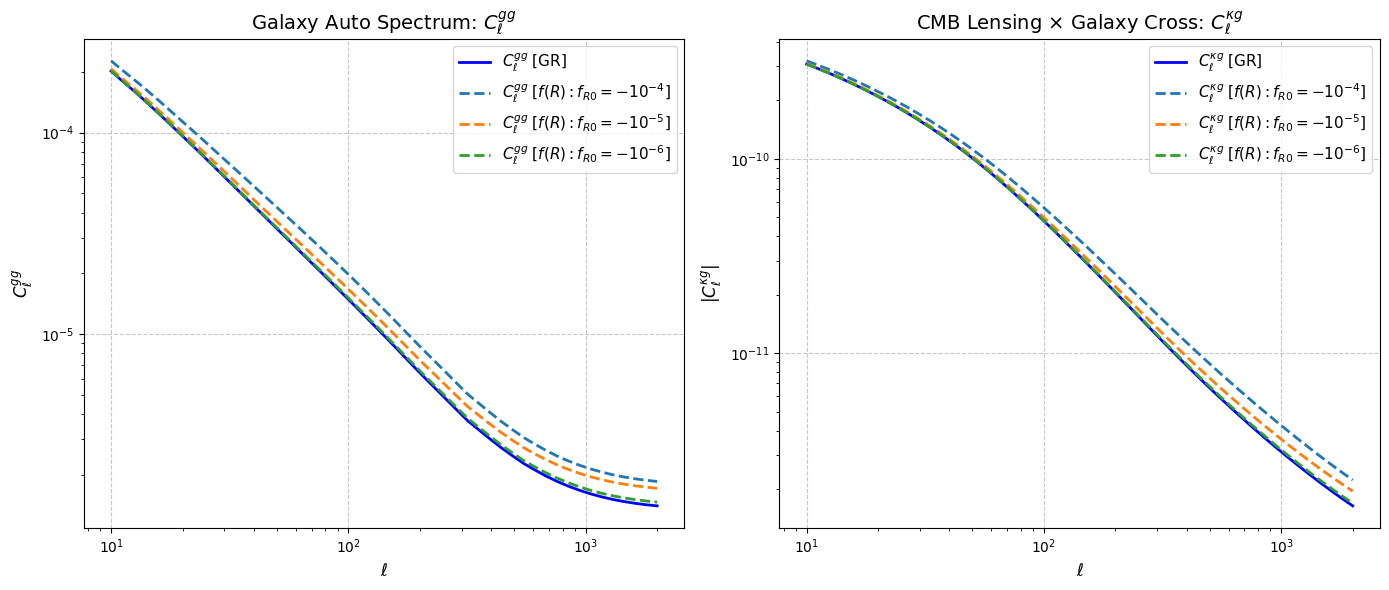

In [8]:
# ========================================================
# Compute and Plot Results
# ========================================================
ell = np.logspace(np.log10(10), np.log10(2000), 50)  # Log-spaced for better sampling

# First, compute results for GR
print("Computing C_ell for GR...")
Cl_gg_gr = compute_Cl_gg(ell, pk_interp_gr, H0, Om0, Om_lambda, b0=2.0)
Cl_kg_gr = compute_Cl_kg(ell, pk_interp_gr, H0, Om0, Om_lambda, b0=2.0)

# Define a list of f(R) values to iterate through
fR_values_to_plot = [4, 5, 6]  # Example: logfR0 values to plot

# Set up figure with two subplots
plt.figure(figsize=(14, 6))

# Plot GR results
plt.subplot(1, 2, 1)
plt.loglog(ell, Cl_gg_gr, 'b-', linewidth=2,
           label=r'$C_\ell^{gg} \; [\mathrm{GR}]$')

plt.subplot(1, 2, 2)
plt.loglog(ell, np.abs(Cl_kg_gr), 'b-', linewidth=2,
           label=r'$C_\ell^{\kappa g} \; [\mathrm{GR}]$')

# Plot f(R) results
for logfR0_val in fR_values_to_plot:
    print(f"Computing C_ell for f(R) with logfR0 = {logfR0_val}...")

    # Set up parameters and compute pk for this f(R)
    params_emantis = {
        "Omega_m": common_params["Omega_m"],
        "Omega_b": common_params["Omega_b"],
        "h": common_params["h"],
        "n_s": common_params["n_s"],
        "sigma8_lcdm": common_params["sigma8"],
        "logfR0": logfR0_val
    }

    emu = NonLinearMGBoostEmulator(verbose=False)  # Re-initialize for each f(R) value
    pk_boost = emu.predict_boost(params_emantis, aexp=common_params["aexp"], k=k)
    pk_fR = pk_nl_total * pk_boost

    # Interpolate the new f(R) power spectrum
    pk_interp_fr = interp1d(np.log(k), np.log(pk_fR + 1e-50),
                            kind='cubic',
                            bounds_error=False,
                            fill_value='extrapolate')

    Cl_gg_fr = compute_Cl_gg(ell, pk_interp_fr, H0, Om0, Om_lambda, b0=2.0)
    Cl_kg_fr = compute_Cl_kg(ell, pk_interp_fr, H0, Om0, Om_lambda, b0=2.0)

    # Plot f(R) results on the same graphs
    plt.subplot(1, 2, 1)
    plt.loglog(ell, Cl_gg_fr, '--', linewidth=2,
               label=rf'$C_\ell^{{gg}} \; [f(R): f_{{R0}}=-10^{{-{logfR0_val}}}]$')

    plt.subplot(1, 2, 2)
    plt.loglog(ell, np.abs(Cl_kg_fr), '--', linewidth=2,
               label=rf'$C_\ell^{{\kappa g}} \; [f(R): f_{{R0}}=-10^{{-{logfR0_val}}}]$')

# Finalize the plot
plt.subplot(1, 2, 1)
plt.xlabel(r'$\ell$', fontsize=12)
plt.ylabel(r'$C_\ell^{gg}$', fontsize=12)
plt.title(r'Galaxy Auto Spectrum: $C_\ell^{gg}$', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, ls='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.xlabel(r'$\ell$', fontsize=12)
plt.ylabel(r'$|C_\ell^{\kappa g}|$', fontsize=12)
plt.title(r'CMB Lensing × Galaxy Cross: $C_\ell^{\kappa g}$', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, ls='--', alpha=0.7)

plt.tight_layout()
plt.show()

- # f(R) vs GR Ratios

Computing C_ell for GR...
Computing C_ell for f(R) with logfR0 = 4...
Computing C_ell for f(R) with logfR0 = 5...
Computing C_ell for f(R) with logfR0 = 6...


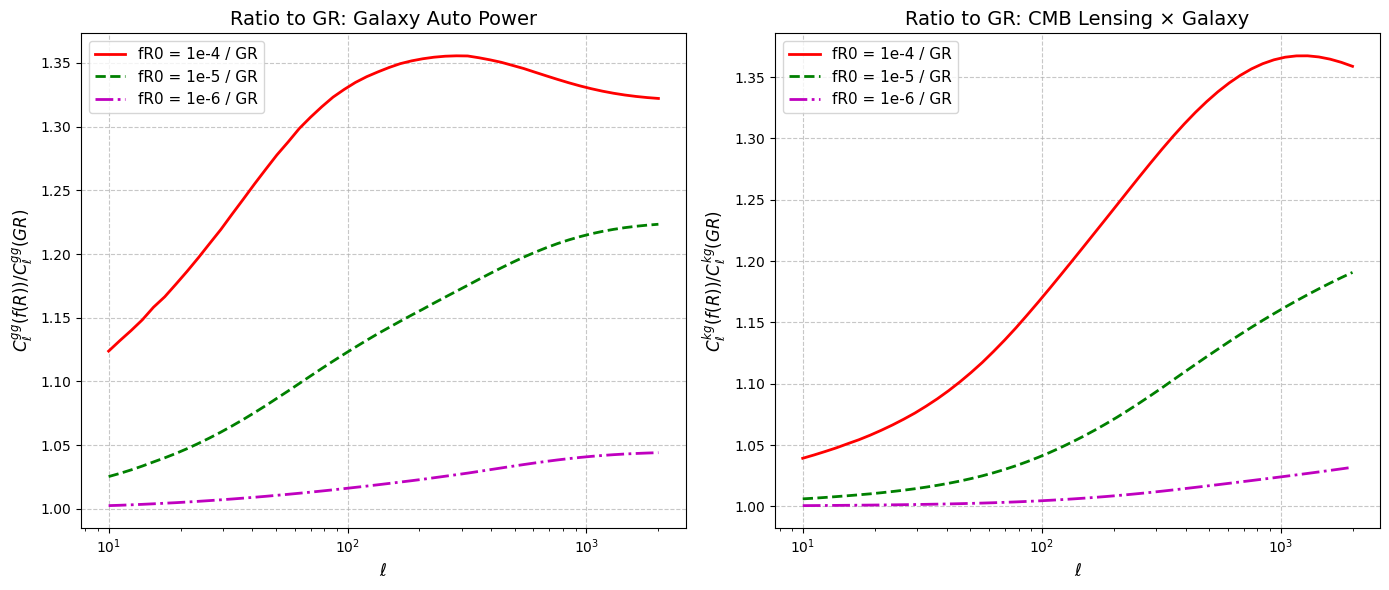

In [10]:
# ========================================================
# Compute and Store Results for Ratio Plots
# ========================================================
ell = np.logspace(np.log10(10), np.log10(2000), 50)  # Log-spaced for better sampling

# Dictionaries to store results
Cl_gg_dict = {}
Cl_kg_dict = {}

# Compute GR
print("Computing C_ell for GR...")
Cl_gg_gr = compute_Cl_gg(ell, pk_interp_gr, H0, Om0, Om_lambda, b0=2.0)
Cl_kg_gr = compute_Cl_kg(ell, pk_interp_gr, H0, Om0, Om_lambda, b0=2.0)

# Store GR in dictionary with key None
Cl_gg_dict[None] = Cl_gg_gr
Cl_kg_dict[None] = Cl_kg_gr

# List of f(R) logfR0 values
fR_values_to_plot = [4, 5, 6]

for logfR0_val in fR_values_to_plot:
    print(f"Computing C_ell for f(R) with logfR0 = {logfR0_val}...")

    params_emantis = {
        "Omega_m": common_params["Omega_m"],
        "Omega_b": common_params["Omega_b"],
        "h": common_params["h"],
        "n_s": common_params["n_s"],
        "sigma8_lcdm": common_params["sigma8"],
        "logfR0": logfR0_val
    }

    emu = NonLinearMGBoostEmulator(verbose=False)
    pk_boost = emu.predict_boost(params_emantis, aexp=common_params["aexp"], k=k)
    pk_fR = pk_nl_total * pk_boost

    pk_interp_fr = interp1d(np.log(k), np.log(pk_fR + 1e-50),
                            kind='cubic', bounds_error=False, fill_value='extrapolate')

    Cl_gg_fr = compute_Cl_gg(ell, pk_interp_fr, H0, Om0, Om_lambda, b0=2.0)
    Cl_kg_fr = compute_Cl_kg(ell, pk_interp_fr, H0, Om0, Om_lambda, b0=2.0)

    # Store in dictionaries
    Cl_gg_dict[logfR0_val] = Cl_gg_fr
    Cl_kg_dict[logfR0_val] = Cl_kg_fr

# ========================================================
# Plot ratios to GR
# ========================================================
colors = ['r', 'g', 'm']         # Example colors for f(R)
line_styles = ['-', '--', '-.']  # Line styles for different f(R)

plt.figure(figsize=(14, 6))

# Galaxy auto spectrum ratio
plt.subplot(1, 2, 1)
for i, logfR0_val in enumerate(fR_values_to_plot):
    ratio = Cl_gg_dict[logfR0_val] / Cl_gg_dict[None]
    plt.semilogx(ell, ratio, color=colors[i % len(colors)],
                 linestyle=line_styles[i % len(line_styles)], linewidth=2,
                 label=f'fR0 = 1e-{logfR0_val} / GR')

plt.xlabel(r'$\ell$', fontsize=12)
plt.ylabel(r'$C_\ell^{gg}(f(R)) / C_\ell^{gg}(GR)$', fontsize=12)
plt.title('Ratio to GR: Galaxy Auto Power', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, ls='--', alpha=0.7)

# CMB lensing × galaxy ratio
plt.subplot(1, 2, 2)
for i, logfR0_val in enumerate(fR_values_to_plot):
    ratio = Cl_kg_dict[logfR0_val] / Cl_kg_dict[None]
    plt.semilogx(ell, ratio, color=colors[i % len(colors)],
                 linestyle=line_styles[i % len(line_styles)], linewidth=2,
                 label=f'fR0 = 1e-{logfR0_val} / GR')

plt.xlabel(r'$\ell$', fontsize=12)
plt.ylabel(r'$C_\ell^{kg}(f(R)) / C_\ell^{kg}(GR)$', fontsize=12)
plt.title('Ratio to GR: CMB Lensing × Galaxy', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, ls='--', alpha=0.7)

plt.tight_layout()
plt.show()